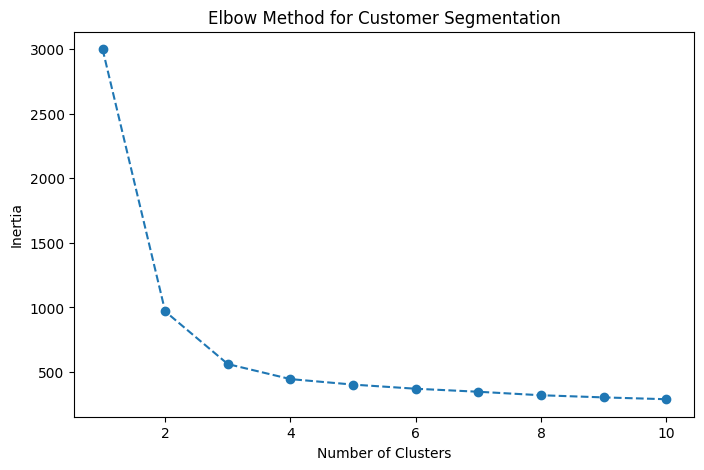

--- Q2 Customer Segmentation ---
Customers have been grouped into 4 segments successfully.
Customer_Segment
0    170
2    165
3     85
1     80
Name: count, dtype: int64


In [1]:
# --- Q2: Customer Segmentation ---
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Load the data
df_q2 = pd.read_csv('q2_customers.csv')

# 2. Scale the data (important for clustering so large numbers don't dominate)
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_q2)

# 3. Use the Elbow Method to find the best number of clusters
inertia = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

# Plot the Elbow Graph
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inertia, marker='o', linestyle='--')
plt.title('Elbow Method for Customer Segmentation')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()

# 4. Apply K-Means with 4 clusters (usually a safe bet based on standard data)
final_kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_q2['Customer_Segment'] = final_kmeans.fit_predict(scaled_data)

print("--- Q2 Customer Segmentation ---")
print("Customers have been grouped into 4 segments successfully.")
print(df_q2['Customer_Segment'].value_counts())